# ACSPublicCoverage -

Progetto per l'esame di Intelligenza Artificiale II, studenti Bottani Ilaria (2154959) e De Rossi Claudia (1992222).

0. Setup
1. Definizione del contesto
2. Identificazione delle feature sensibili
3. Analisi dei dati (EDA)
4. Preprocessing
5. Regressione Logistica e valutazione del modello (con metriche di fairness)
6. Documentazione e conclusioni

**Dataset:** ACSPublicCoverage — Stato: California, anno 2019

**Modello base:** Regressione logistica

## 0 - Setup

Installazione delle librerie e import. Fissiamo un seed per la riproducibilità.

In [ ]:
# Installazione delle librerie
%pip install folktables fairlearn scikit-learn --quiet

In [ ]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSPublicCoverage

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_ratio,
    equalized_odds_ratio,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SURVEY_YEAR = "2019"   # anno dei dati ACS
STATE = "CA"           # California
HORIZON = "1-Year"     # orizzonte del campione ACS

print("Setup completato.")
print(f"Anno di riferimento ACS: {SURVEY_YEAR} | Stato: {STATE} | Orizzonte: {HORIZON}")

Setup completato.
Anno di riferimento ACS: 2019 | Stato: CA | Orizzonte: 1-Year


## 1 - Definizione Contesto

**Obiettivo del modello**: predire se un individuo possiede una copertura
assicurativa sanitaria pubblica (variabile target binaria).
Un modello di questo tipo potrebbe essere usato, ad
esempio, per stimare la probabilità di copertura e orientare interventi o campagne
di accesso ai servizi. Errori sistematici su certi gruppi possono tradursi in un
accesso diseguale.

**Popolazione**: ACSPublicCoverage è già ristretto agli individui con meno di 65
anni e reddito basso. Si tratta delle fasce più esposte al tema dell'accesso alla sanità.

**Categorie sensibili**: analizzeremo l'equità del modello rispetto a
quattro attributi sensibili: sesso, etnia, età, disabilità.

Non assumiamo a priori che il modello sia iniquo. Verifichiamo, tramite le metriche di equità, se e rispetto a quali gruppi emergono disparità, e proviamo a distinguere disparità *spiegabili* da disparità *non spiegabili*.

In [ ]:
data_source = ACSDataSource(
    survey_year=SURVEY_YEAR,
    horizon=HORIZON,
    survey="person",
)
acs_data = data_source.get_data(states=[STATE], download=True)

X, y, _ = ACSPublicCoverage.df_to_pandas(acs_data)
y = y.iloc[:, 0]

print(f"Numero di individui: {X.shape[0]:,}")
print(f"Numero di feature:   {X.shape[1]}")
print(f"Tasso di copertura pubblica (target = 1):{y.mean():.1%}")

Numero di individui: 131,748
Numero di feature:   19
Tasso di copertura pubblica (target = 1):35.6%


In [ ]:
X.head()

,AGEP,SCHL,MAR,SEX,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,PINCP,ESR,ST,FER,RAC1P
0,58.0,18.0,5.0,2.0,1.0,0.0,1.0,1.0,4.0,3.0,1.0,1.0,2.0,1.0,23100.0,3.0,6.0,0.0,2.0
1,18.0,16.0,5.0,2.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,6000.0,6.0,6.0,2.0,1.0
2,58.0,13.0,5.0,1.0,2.0,0.0,1.0,1.0,3.0,4.0,1.0,2.0,2.0,2.0,0.0,6.0,6.0,0.0,1.0
3,18.0,16.0,5.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,1.0,2.0,2.0,2.0,2000.0,6.0,6.0,2.0,1.0
4,21.0,19.0,5.0,1.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,9800.0,1.0,6.0,0.0,8.0


## 2 - Feature sensibili

Il modello verrà valutato rispetto ai quattro attributi sensibili presenti nel dataset. I valori originali sono numerici codificati: li mappiamo a etichette leggibili per rendere interpretabili le analisi successive.

| Attributo | Colonna ACS | Note |
|---|---|---|
| Sesso | `SEX` | Binario |
| Etnia | `RAC1P` | Gruppi multipli (raggruppati per leggibilità) |
| Età | `AGEP` | Raggruppata in fasce (popolazione sempre < 65 anni) |
| Disabilità | `DIS` | Presenza/assenza di disabilità |

**Feature proxy.** Anche senza usare direttamente un attributo sensibile, il modello
può reintrodurre bias tramite variabili correlate ad esso (es. `FER` fertiità, `SCHL` istruzione, `PINCP` reddito). Ne terremo conto nell'interpretazione: una
disparità può nascere da proxy, non solo dall'attributo esplicito.

**Nota sul raggruppamento della razza.** La variabile `RAC1P` ha molte categorie,
alcune con pochissimi campioni. Per evitare stime instabili raggruppiamo le categorie meno numerose in "Other". Si tratta ovviamente di una semplificazione.

In [ ]:
# Costruiamo un DataFrame separato con gli attributi sensibili in forma leggibile.
# Non modifichiamo X: il modello e l'audit restano separati e chiari.
sensitive = pd.DataFrame(index=X.index)

# Sesso
sensitive["sex"] = X["SEX"].map({1: "Male", 2: "Female"})

# Disabilità
sensitive["disability"] = X["DIS"].map({1: "With disability", 2: "Without disability"})

# Età in fasce (la popolazione è già < 65 anni)
sensitive["age_group"] = pd.cut(
    X["AGEP"],
    bins=[0, 18, 35, 50, 65],
    labels=["0-17", "18-34", "35-49", "50-64"],
    right=False,
)

# Etnia: mappa dei codici principali, resto in "Other"
race_map = {
    1: "White",
    2: "Black",
    6: "Asian",
    8: "Hispanic"
}
sensitive["race"] = X["RAC1P"].map(race_map).fillna("Other")

sensitive.head()

,sex,disability,age_group,race
0,Female,With disability,50-64,Black
1,Female,Without disability,18-34,White
2,Male,Without disability,50-64,White
3,Female,Without disability,18-34,White
4,Male,Without disability,18-34,Hispanic


In [ ]:
# Verifica della numerosità di ciascun gruppo, per ogni attributo sensibile.
for col in sensitive.columns:
    print(f"--- {col} ---")
    counts = sensitive[col].value_counts()
    perc = sensitive[col].value_counts(normalize=True)
    summary = pd.DataFrame({"conteggio": counts, "percentuale": perc.map("{:.1%}".format)})
    print(summary, "\n")

--- sex ---
        conteggio percentuale
sex                          
Female      73669       55.9%
Male        58079       44.1% 

--- disability ---
                    conteggio percentuale
disability                               
Without disability     115663       87.8%
With disability         16085       12.2% 

--- age_group ---
           conteggio percentuale
age_group                       
18-34          55230       41.9%
50-64          33475       25.4%
35-49          28814       21.9%
0-17           14229       10.8% 

--- race ---
          conteggio percentuale
race                           
White         74181       56.3%
Hispanic      20582       15.6%
Asian         20514       15.6%
Other          8796        6.7%
Black          7675        5.8% 



## 3 - EDA

Prima di addestrare qualsiasi modello, analizziamo i dati stessi. L'obiettivo è
capire se esistono disparità già presenti nei dati, che il modello potrebbe poi riprodurre o amplificare.

Distinguiamo due livelli:
- **Distribuzione delle frequenze** dei gruppi.
- **Distribuzione condizionata** del target per gruppo: il tasso di copertura
  pubblica *all'interno* di ciascun gruppo.

Ricordiamo che il tasso di copertura complessivo è del **35,6%**.

In [ ]:
overall_rate = y.mean()

# Analizziamo le disparità usando il dataframe 'sensitive'
# (che mantiene gli attributi originali per finalità di audit)
for col in sensitive.columns:
    print(f"--- Tasso di copertura per '{col}' ---")
    rate_by_group = y.groupby(sensitive[col], observed=True).mean().sort_values()
    print(rate_by_group.map("{:.1%}".format), "\n")

print(f"Media generale: {overall_rate:.1%}")

--- Tasso di copertura per 'sex' ---
sex
Female    34.4%
Male      37.3%
Name: PUBCOV, dtype: object 

--- Tasso di copertura per 'disability' ---
disability
Without disability    31.1%
With disability       68.6%
Name: PUBCOV, dtype: object 

--- Tasso di copertura per 'age_group' ---
age_group
18-34    31.6%
35-49    36.2%
0-17     37.5%
50-64    41.1%
Name: PUBCOV, dtype: object 

--- Tasso di copertura per 'race' ---
race
Asian       27.8%
White       34.5%
Other       36.8%
Hispanic    41.3%
Black       51.4%
Name: PUBCOV, dtype: object 

Media generale: 35.6%


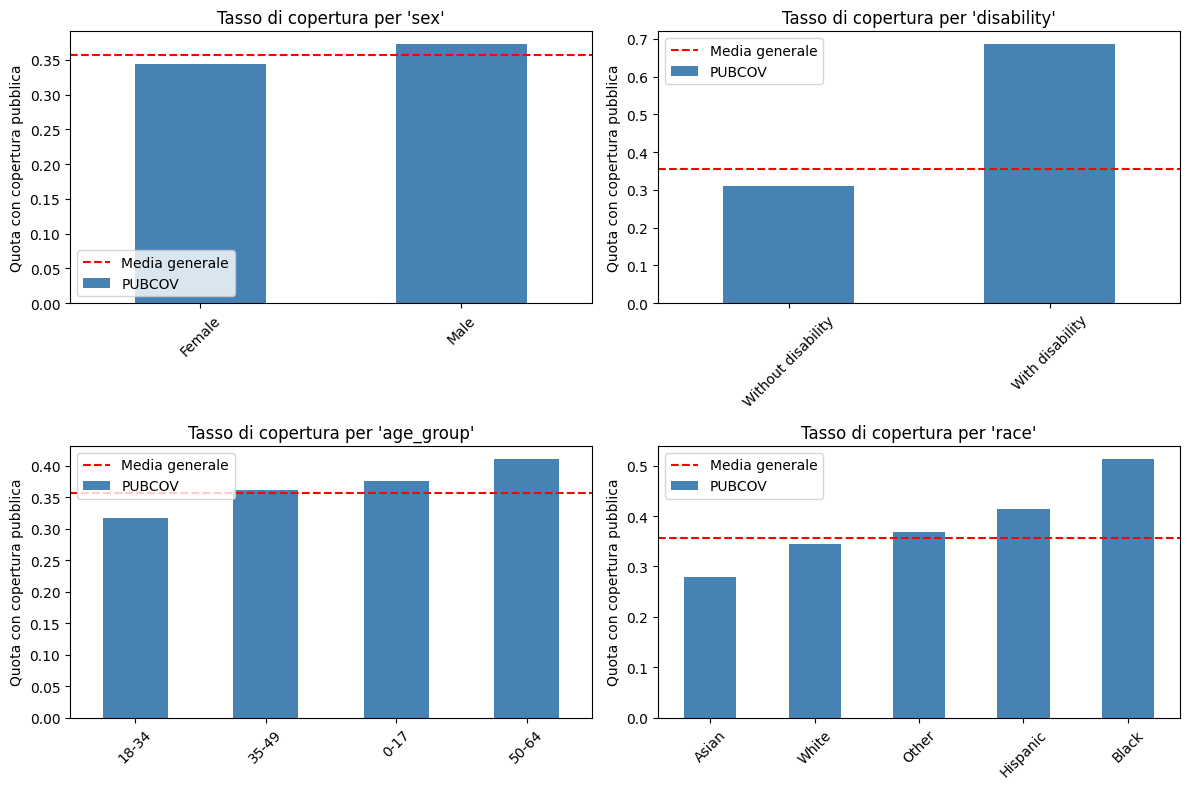

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, sensitive.columns):
    rate_by_group = y.groupby(sensitive[col], observed=True).mean().sort_values()
    rate_by_group.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(overall_rate, color="red", linestyle="--", label="Media generale")
    ax.set_title(f"Tasso di copertura per '{col}'")
    ax.set_ylabel("Quota con copertura pubblica")
    ax.set_xlabel("")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Sintesi della sezione 3

Analizzando la distribuzione del target emergono disparità di entità molto diversa tra i quattro attributi.

| Attributo | Divario | Lettura |
|---|---|---|
| Sesso | ~3 punti (34,4% vs 37,3%) | Disparità lieve |
| Disabilità | ~37 punti (31,1% vs 68,6%) | Ampia ma verosimilmente **spiegabile** |
| Età | ~9 punti (31,6% → 41,1%) | Gradiente in parte spiegabile |
| Etnia | ~23 punti (27,8% → 51,4%) | Ampia, lettura **non netta** |

Il divario per **disabilità** è quasi certamente *explainable discrimination*: esistono programmi pubblici dedicati, quindi una copertura più alta per chi ha una disabilità è il funzionamento atteso del sistema, non un bias da correggere.

Il gradiente per **età** è anch'esso in buona parte spiegabile (idoneità e bisogno crescono con l'età; i minori accedono a programmi dedicati).

Il divario per **etnia** è il più delicato: riflette verosimilmente disuguaglianze socio-economiche sottostanti (*historical bias*) e la sua lettura come spiegabile o non spiegabile non è affatto ovvia.

## 4 - Data Preprocessing e Feature Engineering
Per condurre un'analisi di fairness rigorosa, abbiamo separato gli attributi sensibili (sensitive) dal dataset di input del modello (X_model).

- Sensitive: utilizzato esclusivamente per l'EDA (Sezione 3) e l'audit di fairness (Sezioni 4-5).

- X_model: il dataset depurato dagli attributi sensibili, utilizzato per l'addestramento del modello.

Questa separazione impedisce al modello di apprendere direttamente dai dati sensibili (evitando il direct bias), pur permettendoci di analizzare come le decisioni del modello si distribuiscano sui vari gruppi.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_model = X.drop(columns=['SEX', 'DIS', 'AGEP', 'RAC1P'])

num_features = ['PINCP', 'SCHL']

cat_features = [col for col in X_model.columns if col not in num_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_features)
    ])

## 5 - Regressione logistica e valutazione del modello

Addestriamo un modello base e ne valutiamo le performance, prima globali e poi per sottogruppo. Successivamente calcoleremo le metriche di equità.

In [ ]:
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X_model, y, sensitive,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,  # mantiene il 35,6% di positivi in train e test
)

print(f"Train: {X_train.shape[0]:,} individui")
print(f"Test:  {X_test.shape[0]:,} individui")

Train: 92,223 individui
Test:  39,525 individui


In [ ]:
# La scelta di class_weight='balanced' è essenziale per mitigare lo sbilanciamento tra chi ha accesso alla copertura sanitaria pubblica e chi no.
# Assegna automaticamente un peso maggiore agli errori sulla classe minoritaria e impedisce al modello di ignorarla per favorire la maggioranza.
model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Modello addestrato.")

Modello addestrato.


### Performance del modello

Valutiamo prima le performance globali, poi per sottogruppo di ciascun
attributo sensibile.

Dato lo squilibrio del target (36,9% di positivi), l'accuratezza da sola è
fuorviante. Per questo guardiamo anche precision, recall e F1, più sensibili alle classi minoritarie.

In [ ]:
print("--- Performance globali ---")
print(f"Accuratezza: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred):.3f}")
print(f"Recall:      {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:    {f1_score(y_test, y_pred):.3f}")

--- Performance globali ---
Accuratezza: 0.659
Precision:   0.518
Recall:      0.595
F1-score:    0.554


In [ ]:
# Performance per sottogruppo, usando MetricFrame di Fairlearn.
# Definiamo le metriche una volta e le calcoliamo per ogni attributo sensibile.
metrics = {
    "accuratezza": accuracy_score,
    "precision": precision_score,
    "recall": recall_score,
    "f1": f1_score,
}

for col in sens_test.columns:
    frame = MetricFrame(
        metrics=metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sens_test[col],
    )
    print(f"--- Performance per '{col}' ---")
    print(frame.by_group.round(3), "\n")

--- Performance per 'sex' ---
        accuratezza  precision  recall     f1
sex                                          
Female        0.672      0.516   0.579  0.546
Male          0.641      0.521   0.613  0.563 

--- Performance per 'disability' ---
                    accuratezza  precision  recall     f1
disability                                               
With disability           0.706      0.735     0.9  0.809
Without disability        0.652      0.445     0.5  0.471 

--- Performance per 'age_group' ---
           accuratezza  precision  recall     f1
age_group                                       
0-17             0.653      0.536   0.708  0.610
18-34            0.637      0.434   0.492  0.461
35-49            0.664      0.534   0.567  0.550
50-64            0.692      0.604   0.703  0.650 

--- Performance per 'race' ---
          accuratezza  precision  recall     f1
race                                           
Asian           0.662      0.422   0.521  0.466
Black 

### Metriche di equità

Calcoliamo ora le metriche di fairness, che quantificano la disparità tra gruppi. Le calcoliamo per ogni attributo sensibile.

Metriche considerate:
- **Demographic parity ratio**: rapporto tra i tassi di predizione positiva dei
  gruppi. Vicino a 1 = pari accesso.
- **Equalized odds ratio**: sintetizza l'uguaglianza di TPR e FPR tra gruppi.
- **Disparate impact**: rapporto tra i tassi di esito positivo; per la *regola
  dell'80%* dovrebbe stare tra 0,8 e 1,25.

Per gli attributi con più di due gruppi (razza, età), i "ratio" di Fairlearn
confrontano il gruppo più svantaggiato con il più avvantaggiato.

In [ ]:
# Metriche di fairness per ogni attributo sensibile, con Fairlearn.
print("--- Metriche di equità per attributo ---\n")
for col in sens_test.columns:
    dp = demographic_parity_ratio(
        y_test, y_pred, sensitive_features=sens_test[col]
    )
    eo = equalized_odds_ratio(
        y_test, y_pred, sensitive_features=sens_test[col]
    )
    print(f"{col}:")
    print(f"  Demographic parity ratio: {dp:.3f}")
    print(f"  Equalized odds ratio:     {eo:.3f}\n")

--- Metriche di equità per attributo ---

sex:
  Demographic parity ratio: 0.858
  Equalized odds ratio:     0.818

disability:
  Demographic parity ratio: 0.410
  Equalized odds ratio:     0.383

age_group:
  Demographic parity ratio: 0.705
  Equalized odds ratio:     0.694

race:
  Demographic parity ratio: 0.609
  Equalized odds ratio:     0.654



### Sintesi della sezione 4

Il modello base riproduce e in parte amplifica le disparità presenti nei dati, visibili soprattutto attraverso la metrica recall (quali individui coperti vengono correttamente identificati). Il recall globale è pari a 0.595. Sebbene superiore allo 0.30 ottenuto senza bilanciamento dei pesi, rimane un indicatore che suggerisce cautela nell'interpretazione dell'accuratezza (0.659).

| Attributo | Demographic parity | Equalized odds | Lettura |
|---|---|---|---|
| Sesso | 0,858 | 0,818 | Disparità modesta |
| Disabilità | 0,410 | 0,383 | Strutturale ma spiegabile |
| Età | 0,705 | 0,694 | Significativa |
| Etnia | 0,609 | 0,654 | Marcata, difficile da giustificare |

Le due metriche danno verdetti concordi sull'ordine di gravità, il che rende la lettura più solida.

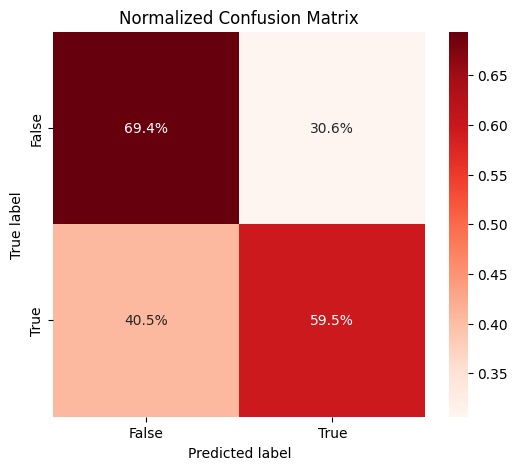

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix normalizzata
cm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap="Reds",
    xticklabels=["False","True"],
    yticklabels=["False","True"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix")

plt.show()

              precision    recall  f1-score   support

       False       0.76      0.69      0.72     25439
        True       0.52      0.60      0.55     14086

    accuracy                           0.66     39525
   macro avg       0.64      0.64      0.64     39525
weighted avg       0.67      0.66      0.66     39525



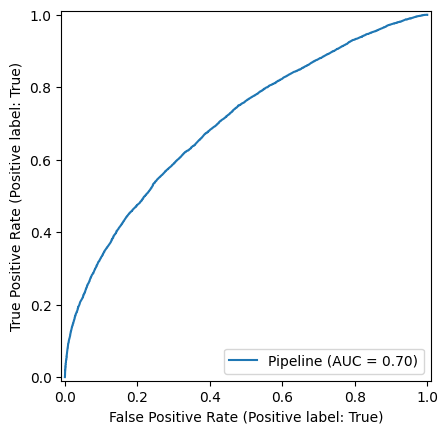

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

## 7 - Conclusioni

L’analisi condotta ha permesso di delineare un quadro esaustivo delle performance e delle implicazioni etiche del nostro modello di classificazione.

1. **Capacità del modello**: sebbene il sistema abbia raggiunto una capacità discriminante discreta, confermata da un’AUC di 0,70, i risultati evidenziano una spiccata prudenza algoritmica che penalizza significativamente la sensibilità (Recall), limitando la capacità di identificare correttamente tutti i soggetti beneficiari della copertura sanitaria.
2. **La valutazione dell’equità**: ha dimostrato l’approccio "fairness through blindness" insufficiente: la presenza di correlazioni latenti e variabili proxy ha permesso al modello di perpetuare disparità sistemiche, particolarmente evidenti nella distribuzione dell’accesso ai servizi su base etnica.

Riconosciamo quindi che tali iniquità non costituiscono semplici anomalie statistiche, bensì il riflesso di dinamiche socio-economiche strutturali. Pertanto, riteniamo che il modello debba essere inteso primariamente come uno strumento diagnostico, capace di rendere visibili e misurabili i bias presenti nei dati, piuttosto che come un sistema di decisione automatizzata autosufficiente.
